In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/raw/demographic_health_data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [6]:
# Variable a predecir: prevalencia de diabetes
target = 'diabetes_prevalence'

# Variables predictoras 
features = [
    'PCTPOVALL_2018',  # % de pobreza
    'Obesity_prevalence',  # % obesidad
    'Heart disease_prevalence',  # % enfermedades cardíacas
    'Unemployment_rate_2018',  # % desempleo
    'Percent of adults with less than a high school diploma 2014-18',  # % sin secundaria
]
data = df[[target] + features].copy()
data = data.dropna()

print(f"Variable a predecir: {target}")
print(f"\nVariables predictoras ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

Variable a predecir: diabetes_prevalence

Variables predictoras (5):
  1. PCTPOVALL_2018
  2. Obesity_prevalence
  3. Heart disease_prevalence
  4. Unemployment_rate_2018
  5. Percent of adults with less than a high school diploma 2014-18


In [7]:
data = df[[target] + features].copy()
data = data.dropna()  # Eliminar filas con datos faltantes
print(f"\n Dataset limpio: {len(data)} condados")


 Dataset limpio: 3140 condados


In [6]:
print(f"\nEstadísticas de Diabetes:")
print(f"  Promedio: {data[target].mean():.2f}%")
print(f"  Mínimo: {data[target].min():.2f}%")
print(f"  Máximo: {data[target].max():.2f}%")


Estadísticas de Diabetes:
  Promedio: 13.07%
  Mínimo: 6.10%
  Máximo: 25.60%


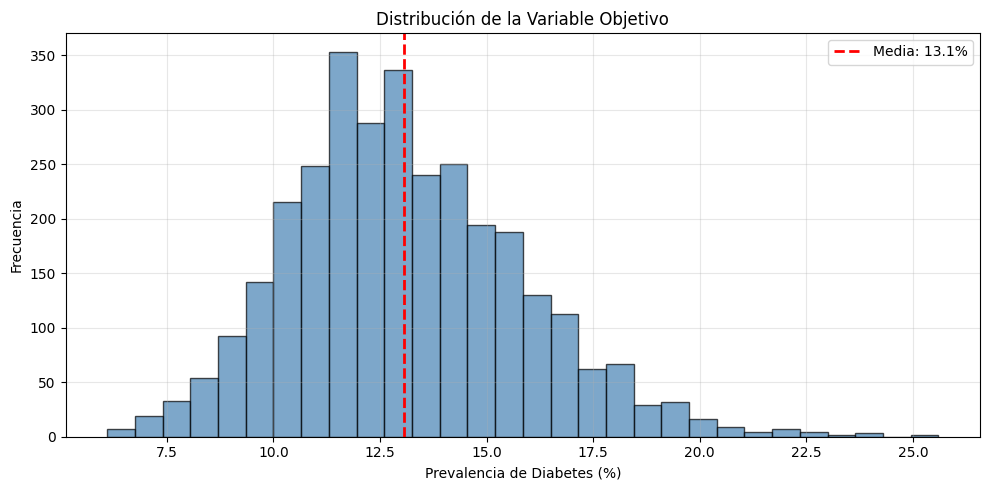

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(data[target], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(data[target].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media: {data[target].mean():.1f}%')
plt.xlabel('Prevalencia de Diabetes (%)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Variable Objetivo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() 
plt.close()


In [13]:
# Matriz de correlación
print(f"\n Correlaciones con {target}:")
correlaciones = data.corr()[target].drop(target).sort_values(ascending=False)
for var, corr in correlaciones.items():
    print(f"   • {var[:45]:45s}: {corr:6.3f}")


 Correlaciones con diabetes_prevalence:
   • Heart disease_prevalence                     :  0.831
   • PCTPOVALL_2018                               :  0.735
   • Obesity_prevalence                           :  0.699
   • Percent of adults with less than a high schoo:  0.699
   • Unemployment_rate_2018                       :  0.491
